# 0. Preparació de dades
Preparau les dades tenint en compte que l'algoritme de clústering que emprarem és sensible a l'escala. 
Inicialment, com que sols anirem amb clústering, escalau el salari i tot, ja que inicialment no tenim y.

In [1]:
import pandas as pd

df = pd.read_csv("./salaries.csv")

In [2]:
df

,kjønn,utdanning,erfaring,arbeidssted,arbeidssituasjon,fag,lønn,bonus?
0,mann,4,7,Agder,"in-house, privat sektor",AI / maskinlæring,865000,Nei
1,mann,5,2,Nordland,"in-house, offentlig/kommunal sektor",AI / maskinlæring,756000,Nei
2,mann,4,30,Oslo,konsulent,AI / maskinlæring,1500000,Nei
3,mann,5,25,Oslo,konsulent,AI / maskinlæring,1200000,Nei
4,mann,9,18,Oslo,"in-house, privat sektor",AI / maskinlæring,1200000,Nei
...,...,...,...,...,...,...,...,...
2677,mann,3,14,Vestfold og Telemark,"in-house, offentlig/kommunal sektor",UX / design,720000,Nei
2678,mann,5,8,Vestland,konsulent,UX / design,875000,Nei
2679,mann,0,23,Viken,"in-house, privat sektor",UX / design,1300000,Nei
2680,mann,3,15,Viken,konsulent,UX / design,1000000,Ja


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

df = df.dropna() 

numeric_col = ['utdanning', 'erfaring', 'lønn']
categorical_col = ['kjønn', 'arbeidssted', 'arbeidssituasjon', 'fag', 'bonus?']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), 
    ('scaler', StandardScaler())                                     
])

categoric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_col),
        ('cat', categoric_transformer, categorical_col)
    ]
)

X_prepared = preprocessor.fit_transform(df)

cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_col).tolist()
columns_transformed = numeric_col + cat_features

df = pd.DataFrame(X_prepared, columns=columns_transformed)

print(df.head())

   utdanning  erfaring      lønn  kjønn_annet / ønsker ikke oppgi  \
0  -0.044875 -0.201915 -0.114644                              0.0   
1   0.307039 -0.845527 -0.492815                              0.0   
2  -0.044875  2.758702  2.088463                              0.0   
3   0.307039  2.115090  1.047625                              0.0   
4   1.714694  1.214033  1.047625                              0.0   

   kjønn_kvinne  kjønn_mann  arbeidssted_Agder  arbeidssted_Innlandet  \
0           0.0         1.0                1.0                    0.0   
1           0.0         1.0                0.0                    0.0   
2           0.0         1.0                0.0                    0.0   
3           0.0         1.0                0.0                    0.0   
4           0.0         1.0                0.0                    0.0   

   arbeidssted_Møre og Romsdal  arbeidssted_Nordland  ...  fag_devops / drift  \
0                          0.0                   0.0  ...        

# 1. Clustering. Sense eliminar característica de l'import del salari

Empra K-Means per tal de segmentar els nostres usuaris.

Obté un valor apropiat per al nombre de clústers, explorant les inèrcies i els scores de silueta. Justifica la resposta.

Explora els perfils dels clústers majoritaris.

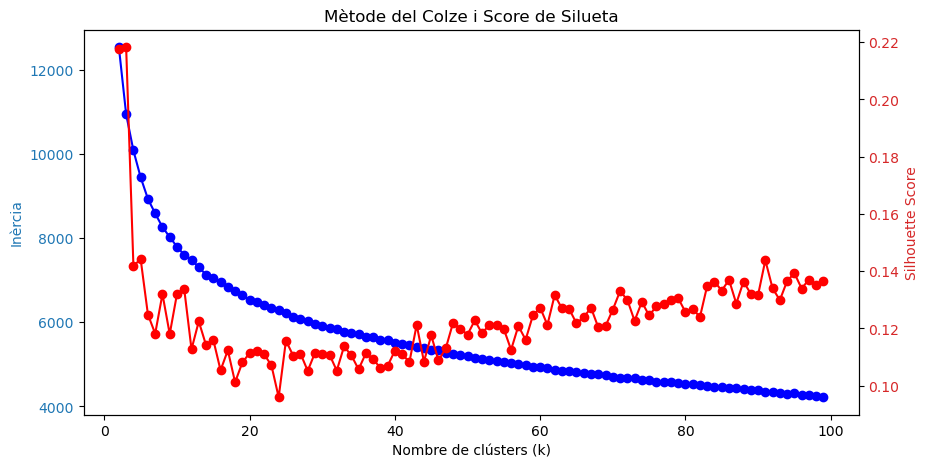

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 100)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prepared)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prepared, kmeans.labels_))

# Visualització dels resultats
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Nombre de clústers (k)')
ax1.set_ylabel('Inèrcia', color='tab:blue')
ax1.plot(K_range, inertias, 'bo-', label='Inèrcia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouettes, 'ro-', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Mètode del Colze i Score de Silueta')
plt.show()

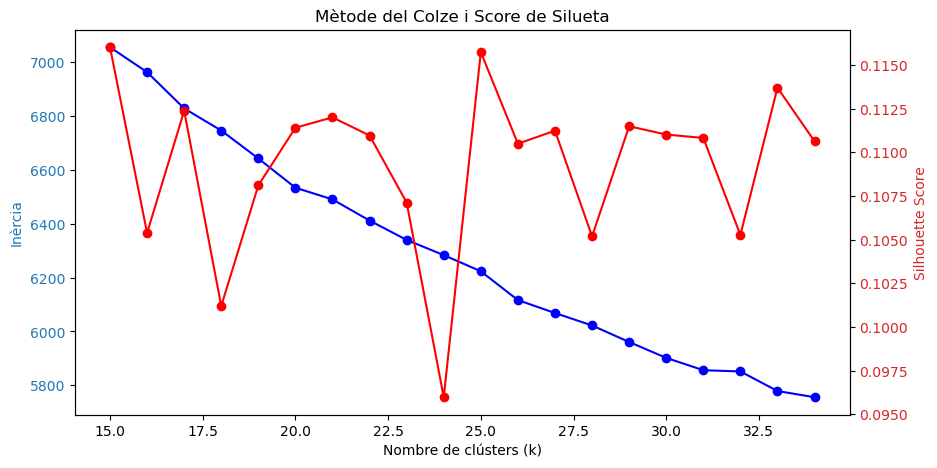

In [5]:

inertias = []
silhouettes = []
K_range = range(15, 35)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prepared)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prepared, kmeans.labels_))

# Visualització dels resultats
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Nombre de clústers (k)')
ax1.set_ylabel('Inèrcia', color='tab:blue')
ax1.plot(K_range, inertias, 'bo-', label='Inèrcia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouettes, 'ro-', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Mètode del Colze i Score de Silueta')
plt.show()

Justificacion de respuesta

La k seleccionada sera 25, se a elegido ya que se a obtenido un rango favorable del codo donde se desaceleraba en este caso a sido entre 15 y 35 y se a obtado posteriormente a la k de 25 ya que es la que tiene la mayor Score de Silueta

Amb k=35, el score de silueta mitjà és: 0.1057


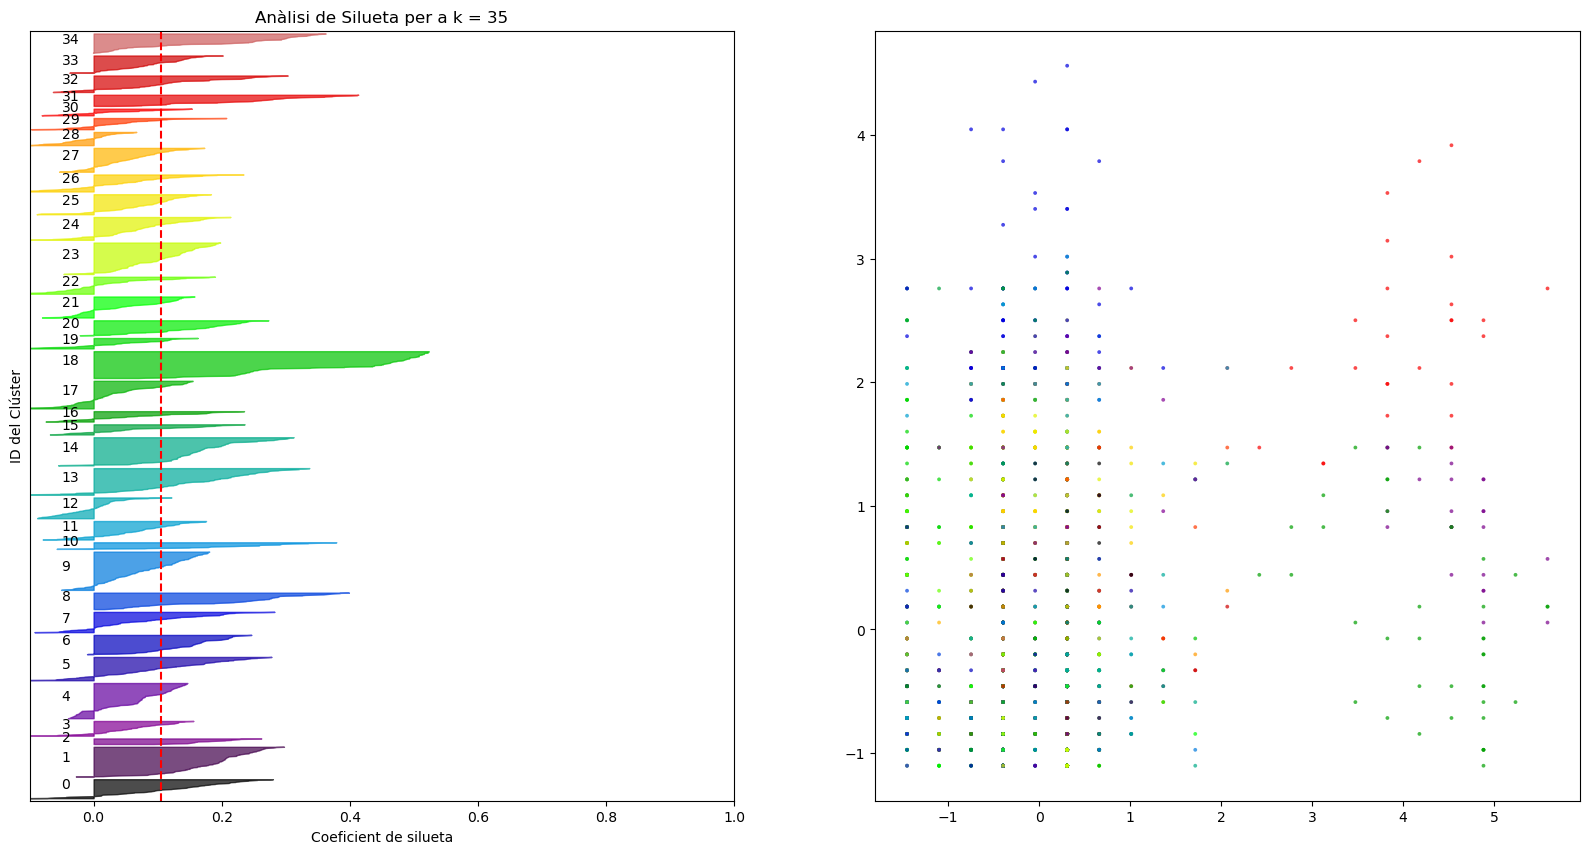

In [6]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Triem el teu valor justificat
n_clusters = 35
X = X_prepared 

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(20, 10) # Una mica més gran per encabir els 25 clústers

# Configuració eix Silueta
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
cluster_labels = clusterer.fit_predict(X)

silhouette_avg = silhouette_score(X, cluster_labels)
print(f"Amb k={n_clusters}, el score de silueta mitjà és: {silhouette_avg:.4f}")

sample_silhouette_values = silhouette_samples(X, cluster_labels)

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Posem el número del clúster (només si el grup és prou gran per llegir-lo)
    if size_cluster_i > 20: 
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_title(f"Anàlisi de Silueta per a k = {n_clusters}")
ax1.set_xlabel("Coeficient de silueta")
ax1.set_ylabel("ID del Clúster")
ax1.set_yticks([]) 

# Gràfic de dispersió (projecció de les dues primeres variables)
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
ax2.scatter(X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

plt.show()

# 2. Detecció d'anomalies

In [7]:
import numpy as np

# Obtenim la matriu de distancies amb les dades preparades
distancies_matriu = kmeans.transform(X_prepared)

# nomes amb la distancia al centroide del seu propi cluster (la minima)
distancies_minimes = np.min(distancies_matriu, axis=1)

# calculem el threshold basat nomes en les distancies al seu grup
threshold = np.mean(distancies_minimes) + 3 * np.std(distancies_minimes)
print(f"El umbral es: {threshold}")

# Busquem les anomalies 
# Comprovem quines d'aquestes distancies minimes superen el humbral
anomalies_mask = distancies_minimes > threshold

# Filtrem en el DataFrame original (per poder llegir qui són)
anomalies = df[anomalies_mask] 

print(f"Nombre d'anomalies detectades: {len(anomalies)}")
print(anomalies)

El umbral es: 2.621183705211763
Nombre d'anomalies detectades: 10
      utdanning  erfaring      lønn  kjønn_annet / ønsker ikke oppgi  \
27     4.530005  2.501257  3.649720                              0.0   
81     0.307039 -0.974250  2.088463                              0.0   
231    1.362780  0.184253  3.823193                              0.0   
1056   2.066608  0.312975 -1.380997                              0.0   
1079  -0.044875  2.758702  5.904869                              0.0   
1344  -0.396789 -0.716805  4.517085                              0.0   
2019   2.418522  0.441698  0.596595                              0.0   
2416   2.770436  2.115090  2.608882                              0.0   
2449   4.178091  3.788482 -0.687105                              0.0   
2502  -0.044875  4.432095  0.700679                              0.0   

      kjønn_kvinne  kjønn_mann  arbeidssted_Agder  arbeidssted_Innlandet  \
27             0.0         1.0                0.0                

Empra el clústering de l'apartat anterior per tal de detectar anomalies seguint la regla del 3 sigma. Hi ha anomalies? Quines són?
si, son las 10 que se muestran en la tabla anterior

# 3. Reducció de dimensionalitat per a regressió

Deixa apart la característica del salari. Aquesta serà la nostra 'y'.

In [8]:
X = df.drop('lønn', axis=1)
y = df['lønn']

X

,utdanning,erfaring,kjønn_annet / ønsker ikke oppgi,kjønn_kvinne,kjønn_mann,arbeidssted_Agder,arbeidssted_Innlandet,arbeidssted_Møre og Romsdal,arbeidssted_Nordland,arbeidssted_Oslo,...,fag_devops / drift,fag_embedded / IOT / maskinvare,fag_frontend,fag_fullstack,fag_ledelse/administrativt,fag_programvare,fag_sikkerhet,fag_testing,bonus?_Ja,bonus?_Nei
0,-0.044875,-0.201915,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.307039,-0.845527,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.044875,2.758702,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.307039,2.115090,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.714694,1.214033,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2677,-0.396789,0.699143,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2678,0.307039,-0.073192,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2679,-1.452530,1.857645,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2680,-0.396789,0.827865,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Fes un split de train i un de test. 

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


Crea un regressor que calculi es costs generats emprant un Support Vector Regressor. No cal regularitzar.

In [23]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

regressor_svr = SVR(kernel='rbf',C=1.0 ,epsilon=0.1)

regressor_svr.fit(X_train, y_train)

y_pred = regressor_svr.predict(X_test)
y_pred

array([-4.46118787e-01,  3.72855340e-02, -8.67918997e-01,  2.03276367e-01,
        5.88487711e-02,  9.02246066e-01,  6.72845846e-01,  9.93945175e-01,
        3.05644098e-01,  7.66799178e-01,  1.00195977e+00,  1.23951600e-01,
       -8.18842303e-01, -9.17226445e-01, -5.72301042e-01,  6.55317327e-01,
        9.76201370e-01, -7.96562900e-01, -3.44875892e-01, -5.88449023e-01,
        9.60434366e-01, -1.12878467e+00,  4.35564638e-01, -3.24493337e-01,
        5.53381468e-01, -4.54767789e-01, -3.77031597e-01,  3.72141967e-01,
        9.65991372e-01, -9.57407595e-01, -8.56847311e-01, -9.12335985e-01,
        7.99510036e-01, -8.64290489e-01,  1.43634739e-01,  7.09954985e-01,
       -2.43789934e-01,  5.53423106e-01, -8.55236409e-01, -3.11247244e-01,
        1.14619176e+00,  1.63660472e-01, -7.56093510e-01, -6.54789277e-01,
       -5.18109513e-01, -6.21062004e-01,  8.84402122e-01, -9.75604611e-01,
       -4.20120889e-01, -9.30363793e-01, -1.74957998e-01, -6.77185873e-01,
        1.56276028e-01, -

Mostra els resultats obtinguts emprant la mètrica que consideris adeqüada emprant validació creuada.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# Métricas de error solicitadas
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')

MAE: 0.4463
MSE: 0.5109
RMSE: 0.7148


Emprant PCA, redueix la dimensionalitat per tal de preservar un mínim d'un 90% de variança. Quants de components ens han quedat?

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

n_components = pca.n_components_
varianca_explicada = sum(pca.explained_variance_ratio_) * 100

print(f"Nombre de components per retenir el 90%: {n_components}")
print(f"Variança total explicada: {varianca_explicada:.2f}%")

Nombre de components per retenir el 90%: 14
Variança total explicada: 90.53%


Agafa el component que expliqui la major variança. Quina de les columnes originals és la que te major pes sobre ell?

In [32]:
import pandas as pd
import numpy as np

pesos_pc1 = pca.components_[0]

df_pesos = pd.DataFrame({'Columna': X_train.columns, 'Pes': pesos_pc1})

df_pesos['Pes_Absolut'] = df_pesos['Pes'].abs()
df_pesos_ordenat = df_pesos.sort_values(by='Pes_Absolut', ascending=False)

print("--- Pesos de les columnes originals sobre el PC1 ---")
print(df_pesos_ordenat.head(5))

columna_top = df_pesos_ordenat.iloc[0]['Columna']
valor_pes = df_pesos_ordenat.iloc[0]['Pes']

print(f"\nLa columna amb major pes sobre el PC1 és: '{columna_top}' amb un pes de {valor_pes:.4f}")

--- Pesos de les columnes originals sobre el PC1 ---
          Columna       Pes  Pes_Absolut
1        erfaring  0.758485     0.758485
0       utdanning  0.638716     0.638716
33  fag_fullstack -0.060128     0.060128
38      bonus?_Ja  0.047675     0.047675
39     bonus?_Nei -0.047675     0.047675

La columna amb major pes sobre el PC1 és: 'erfaring' amb un pes de 0.7585


Crea un SVR de nou que prengui els valors del PCA. Quins resultats ha obtingut sobre la validació creuada aquesta vegada?

In [33]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

regressor_svr_pca = SVR(kernel='rbf', C=1.0, epsilon=0.1)

regressor_svr_pca.fit(X_train_pca, y_train)

y_pred = regressor_svr_pca.predict(X_test_pca)
y_pred


array([-4.95907415e-01,  3.83452471e-02, -9.55409061e-01,  4.55365179e-01,
       -1.67612940e-01,  9.70305655e-01,  6.60637976e-01,  1.05591482e+00,
        2.58755440e-01,  6.80321324e-01,  9.72063834e-01,  1.48201192e-01,
       -8.25630577e-01, -9.32160022e-01, -5.55709099e-01,  4.97976960e-01,
        7.91385319e-01, -7.57519076e-01, -7.10945059e-01, -6.10990089e-01,
        9.69548933e-01, -1.03022156e+00,  3.06943248e-01, -4.48726735e-01,
       -1.92669588e-01, -6.24283499e-01, -4.04812338e-01,  3.12288541e-01,
        9.38410438e-01, -9.96910773e-01, -8.37081781e-01, -8.91355767e-01,
        7.81916343e-01, -8.54473570e-01,  2.24965618e-01,  7.25195425e-01,
       -1.73398434e-01,  4.69052232e-01, -7.75111186e-01, -2.89679237e-01,
        1.09365146e+00, -2.25737893e-01, -7.54502849e-01, -5.38307521e-01,
       -9.68141331e-01, -6.05811252e-01,  8.20896611e-01, -8.04801063e-01,
       -2.65603141e-01, -8.61062191e-01, -2.44915420e-01, -6.48769378e-01,
        1.83053236e-01, -

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# Métricas de error solicitadas
print(f'MAE (Test): {mean_absolute_error(y_test, y_pred):.4f}')
print(f'MSE (Test): {mean_squared_error(y_test, y_pred):.4f}')
print(f'RMSE (Test): {root_mean_squared_error(y_test, y_pred):.4f}')

MAE (Test): 0.4579
MSE (Test): 0.5689
RMSE (Test): 0.7542


Torna a realitzar les mateixes accions que abans, aquesta vegada però amb amb IncrementalPCA amb un batch size del 10% el nombre de files i amb KernelPCA amb el kernel rbf.


In [35]:
from sklearn.decomposition import IncrementalPCA, KernelPCA
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import numpy as np

# INCREMENTAL PCA
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

batch_size_10 = int(len(X_train) * 0.1)

ipca = IncrementalPCA(n_components=None, batch_size=batch_size_10) # n_components es pot ajustar
X_train_ipca = ipca.fit_transform(X_train)
X_test_ipca = ipca.transform(X_test)

svr_model.fit(X_train_ipca, y_train)
y_pred_ipca = svr_model.predict(X_test_ipca)

y_pred_ipca



array([-4.08015765e-01,  2.85403329e-02, -9.29399029e-01,  1.20423101e-01,
        7.48006094e-02,  9.34680212e-01,  6.67937981e-01,  1.10119303e+00,
        3.33738412e-01,  7.55923974e-01,  9.85496862e-01,  1.76201799e-01,
       -8.24742111e-01, -9.20336567e-01, -5.43084427e-01,  5.29433908e-01,
        9.18059325e-01, -7.90141777e-01, -6.51482926e-01, -5.85714270e-01,
        9.31971239e-01, -1.07730802e+00,  3.80784129e-01, -4.05086191e-01,
        5.79675295e-01, -4.48438726e-01, -3.50038672e-01,  3.90362212e-01,
        9.58237191e-01, -9.56778406e-01, -8.41243987e-01, -9.13994547e-01,
        7.91518489e-01, -8.44348878e-01,  2.42667592e-01,  7.42350624e-01,
       -2.48817872e-01,  5.01580252e-01, -8.44539318e-01, -3.09599742e-01,
        1.15140985e+00,  1.45039337e-01, -7.25598591e-01, -6.88133926e-01,
       -4.82496172e-01, -6.44152534e-01,  8.31684610e-01, -1.02057032e+00,
       -3.60880662e-01, -8.80970567e-01, -2.29503297e-01, -6.73500196e-01,
        1.37685699e-01, -

In [38]:
print(f"IncrementalPCA (Batch Size: {batch_size_10}) ---")
print(f'MAE: {mean_absolute_error(y_test, y_pred_ipca):.4f}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ipca):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_ipca):.4f}\n')

IncrementalPCA (Batch Size: 201) ---
MAE: 0.4502
MSE: 0.5178
RMSE: 0.7196



In [39]:

# KERNEL PCA (RBF)
kpca = KernelPCA(kernel='rbf', n_components=None) # n_components sol ser necessari reduir-lo si hi ha moltes columnes
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

svr_model.fit(X_train_kpca, y_train)
y_pred_kpca = svr_model.predict(X_test_kpca)
y_pred_kpca

array([-3.89947545e-01,  2.00048724e-02, -9.19247651e-01,  1.70806190e-01,
        1.30403845e-01,  9.59414852e-01,  6.79836639e-01,  1.09477781e+00,
        2.77200130e-01,  7.61689189e-01,  9.90620278e-01,  1.75798749e-01,
       -8.25641473e-01, -9.20832711e-01, -5.18824944e-01,  4.81317368e-01,
        8.93071900e-01, -7.95838479e-01, -8.08917166e-01, -5.97989228e-01,
        9.12664855e-01, -1.08282946e+00,  3.38533640e-01, -4.19212514e-01,
        6.06419256e-01, -4.58765976e-01, -3.25657271e-01,  3.77317207e-01,
        9.62109608e-01, -9.67089894e-01, -8.36047290e-01, -9.18914746e-01,
        8.01047328e-01, -8.32691376e-01,  2.77465212e-01,  7.24095294e-01,
       -2.11930332e-01,  4.41761335e-01, -8.44935827e-01, -3.11798813e-01,
        1.09642844e+00,  1.52236217e-01, -6.68779346e-01, -7.06850189e-01,
       -4.51676703e-01, -6.35591096e-01,  8.26345878e-01, -1.03115406e+00,
       -3.14899926e-01, -8.12126724e-01, -2.18397436e-01, -6.97914425e-01,
        1.37245806e-01, -

In [40]:
print(f'MAE: {mean_absolute_error(y_test, y_pred_kpca):.4f}')
print(f'MSE: {mean_squared_error(y_test, y_pred_kpca):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_kpca):.4f}')

MAE: 0.4532
MSE: 0.5196
RMSE: 0.7208


# 4. Reducció de dimensionalitat per a visualització

Emprant PCA i totes les dades de X, projecta el dataset en els dos components principals i visualitza l'scatter plot. Quina pinta te si afegim els salaris com a hue?

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X) 

X_pca

array([[-0.16518991, -0.10034214],
       [-0.38945972,  0.69553944],
       [ 1.91996546, -1.77173575],
       ...,
       [ 0.34762571, -2.4974275 ],
       [ 0.41013174, -0.74926528],
       [-0.99655842,  0.27579596]], shape=(2682, 2))

In [44]:
import pandas as pd

df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_plot['Salari'] = y.values # Afegim la columna de salaris per al color

df_plot

,PC1,PC2,Salari
0,-0.165190,-0.100342,-0.114644
1,-0.389460,0.695539,-0.492815
2,1.919965,-1.771736,2.088463
3,1.703282,-1.090160,1.047625
4,2.050963,0.277386,1.047625
...,...,...,...
2677,0.222063,-0.867367,-0.617716
2678,0.145320,0.286672,-0.079950
2679,0.347626,-2.497427,1.394571
2680,0.410132,-0.749265,0.353733


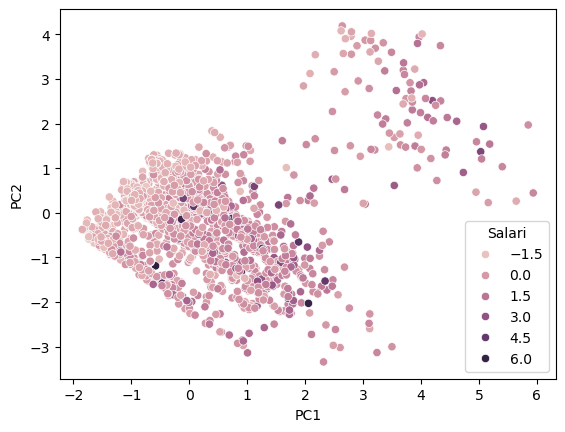

In [56]:
plt.figure()
scatter = sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Salari')
plt.show()

Realitza les mateixes accions, però aquesta vegada projecta sobre 3 components en lloc de 2. Realitza dues visualitzacions, una amb un gràfic estàtic en 3d i una altra amb una visualització dinàmica emprant plotly. 

In [57]:
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(X) 

X_pca

array([[-0.16518991, -0.10034214, -0.83477098],
       [-0.38945972,  0.69553944, -0.59551685],
       [ 1.91996546, -1.77173575,  0.44331586],
       ...,
       [ 0.34762571, -2.4974275 , -0.45901545],
       [ 0.41013174, -0.74926528,  1.25102809],
       [-0.99655842,  0.27579596, -0.81775629]], shape=(2682, 3))

In [58]:
import pandas as pd

df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2','PC3'])
df_plot['Salari'] = y.values # Afegim la columna de salaris per al color

df_plot

,PC1,PC2,PC3,Salari
0,-0.165190,-0.100342,-0.834771,-0.114644
1,-0.389460,0.695539,-0.595517,-0.492815
2,1.919965,-1.771736,0.443316,2.088463
3,1.703282,-1.090160,0.338492,1.047625
4,2.050963,0.277386,-0.864317,1.047625
...,...,...,...,...
2677,0.222063,-0.867367,-0.369006,-0.617716
2678,0.145320,0.286672,0.027012,-0.079950
2679,0.347626,-2.497427,-0.459015,1.394571
2680,0.410132,-0.749265,1.251028,0.353733


Realitza les mateixes accions, però aquesta vegada projecta sobre 3 components en lloc de 2. Realitza dues visualitzacions, una amb un gràfic estàtic en 3d i una altra amb una visualització dinàmica emprant plotly. 

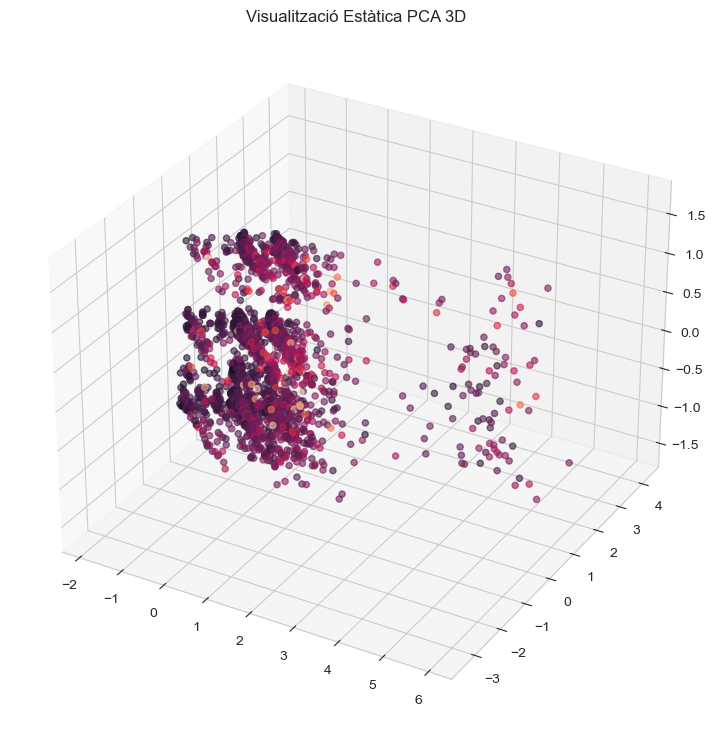

In [67]:
# Visualització Estàtica PCA 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_plot['PC1'],
                      df_plot['PC2'],
                      df_plot['PC3'],
                      c=df_plot['Salari'], 
                      alpha=0.6,
                     )
ax.set_title('Visualització Estàtica PCA 3D')

plt.show()

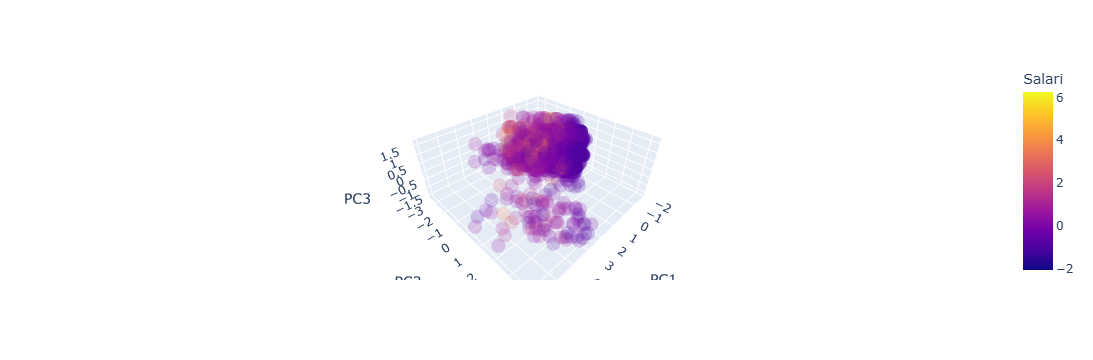

In [70]:
import plotly.express as px
# visualització dinàmica emprant plotly

fig = px.scatter_3d(df_plot, x='PC1', y='PC2', z='PC3',
                    color='Salari', opacity=0.2)
fig.show()